<!-- # Práctico 1 — Análisis exploratorio y visualización

**Mentoría M09 — El impacto de la IA en la fuerza laboral**

Dataset: [diplodatos-ai-impact-workforce](https://github.com/carolinapepe/diplodatos-ai-impact-workforce)

---

## Índice

| Sección | Contenido |
|---|---|
| [1. Descripción general del dataset](#1) | Registros, variables y relación entre los tres archivos |
| [2. Análisis univariado](#2) | Distribuciones de las variables clave, contexto geográfico y estructura de la variación |
| [3. Análisis bivariado y comparaciones](#3) | Perfil por industria, inversión vs. retorno económico, automatización vs. empleo |
| [4. Hipótesis de investigación](#4) | Dos preguntas surgidas de la exploración y su abordaje técnico |
| [5. Conclusiones parciales](#5) | Síntesis de hallazgos y preguntas abiertas |

**Preguntas que motivan el trabajo:** ¿La IA va a destruir trabajos? ¿Es rentable invertir en IA para mejorar la productividad? -->

<a id="1"></a>

---

# 1. Descripción general del dataset

> **Consigna**
> - ¿Cuántos registros y variables tiene cada archivo? ¿Qué tipo de variables hay (numéricas, categóricas)?
> - ¿Qué representa cada archivo y cómo se relacionan entre sí?

## 1.1 Librerías y carga de datos

In [1]:
# Cargamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Exploramos los registros y variables de cada dataset
# Se corrigen las URLs para apuntar al contenido "raw" de los archivos en GitHub.
df1_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/ai_company_adoption.csv"
df2_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/ai_industry_summary.csv"
df3_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/country_ai_index.csv"

df1 = pd.read_csv(df1_url)
df2= pd.read_csv(df2_url)
df3 = pd.read_csv(df3_url)

## 1.2 Cantidad de registros, variables y tipos de dato

Se revisa cada archivo con `.shape` (registros × variables) y `.info()` (tipo de dato y nulos por columna).

**`ai_company_adoption.csv` (`df1`) — encuestas trimestrales a nivel empresa**

In [3]:
print(f"Shape of df1: {df1.shape}")
df1.info()

Shape of df1: (150025, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            15

**`ai_industry_summary.csv` (`df2`) — resumen agregado por industria**

In [4]:
print(f"Shape of df2: {df2.shape}")
df2.info()

Shape of df2: (9, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      object 
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), object(1)
memory usage: 708.0+ bytes


**`country_ai_index.csv` (`df3`) — indicadores agregados por país**

In [5]:
print(f"Shape of df3: {df3.shape}")
df3.info()

Shape of df3: (30, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     object 
 1   region                      30 non-null     object 
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     object 
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


## 1.3 Qué representa cada archivo y cómo se relacionan

El dataset se compone de 3 archivos csv. "ai_company_adoption" es el conjunto de encuestas trimestrales donde se describen empresas y variables de impacto y adopcion de IA. "ai_industry_summary" es un resumen de los promedios de las varaibles del impacto de la IA por tipo de insutria. "country_ai_index" resumen variables economicas y de adopcion de IA por paises y regiones.


## 1.4 Clasificación de las variables por rol

Clasificamos las variables de `df1` en grupos para una mejor orientación:

**A. Identificación / metadata** — no aportan al análisis, pero sirven para trazabilidad
`response_id`, `company_id`, `survey_year`, `quarter`, `survey_source`, `data_collection_method`

**B. Contexto geográfico / sectorial**
`country`, `region`, `industry`

**C. Características estructurales de la empresa**
`company_size`, `num_employees`, `annual_revenue_usd_millions`, `company_founding_year`, `company_age`, `company_age_group`

**D. Adopción de IA** — cuánto y cómo usan IA
`ai_adoption_rate`, `ai_adoption_stage`, `years_using_ai`, `ai_primary_tool`, `num_ai_tools_used`, `ai_use_case`, `ai_projects_active`, `ai_training_hours`, `ai_budget_percentage`, `ai_maturity_score`, `ai_investment_per_employee`

**E. Gobernanza y riesgo**
`ai_failure_rate`, `regulatory_compliance_score`, `data_privacy_level`, `ai_ethics_committee`, `ai_risk_management_score`

**F. Impacto en personas / trabajo**
`remote_work_percentage`, `employee_satisfaction_score`, `task_automation_rate`, `time_saved_per_week`, `jobs_displaced`, `jobs_created`, `reskilled_employees`

**G. Impacto en el negocio (performance)**
`productivity_change_percent`, `revenue_growth_percent`, `cost_reduction_percent`, `innovation_score`, `customer_satisfaction`

<a id="2"></a>

---

# 2. Análisis univariado

> **Consigna**
> Explorá al menos 5 variables que consideres relevantes para el proyecto. Para cada una:
> - Describí su distribución (histograma, boxplot, frecuencias según corresponda)
> - Comentá lo que ves: ¿es lo que esperabas? ¿hay algo llamativo?

## 2.1 Criterio de selección de variables

En principio las preguntas principales de investigacion son

-La IA va destruir trabajos?
-Es rentable invertir en IA para mejorar la productividad?

Por lo que haremos una exploracion de variables que esten relacionadas a estas preguntas

## 2.2 Distribución de las variables clave

Se exploran **9 variables** de los grupos D, F y G (por encima de las 5 pedidas): las tres de impacto laboral (`jobs_displaced`, `jobs_created`, `reskilled_employees`), la tasa de automatización, las dos de inversión en IA (`ai_budget_percentage`, `ai_investment_per_employee`) y las tres de retorno económico (`productivity_change_percent`, `revenue_growth_percent`, `cost_reduction_percent`).

Primero los histogramas, luego la tabla de estadísticos descriptivos que los acompaña.

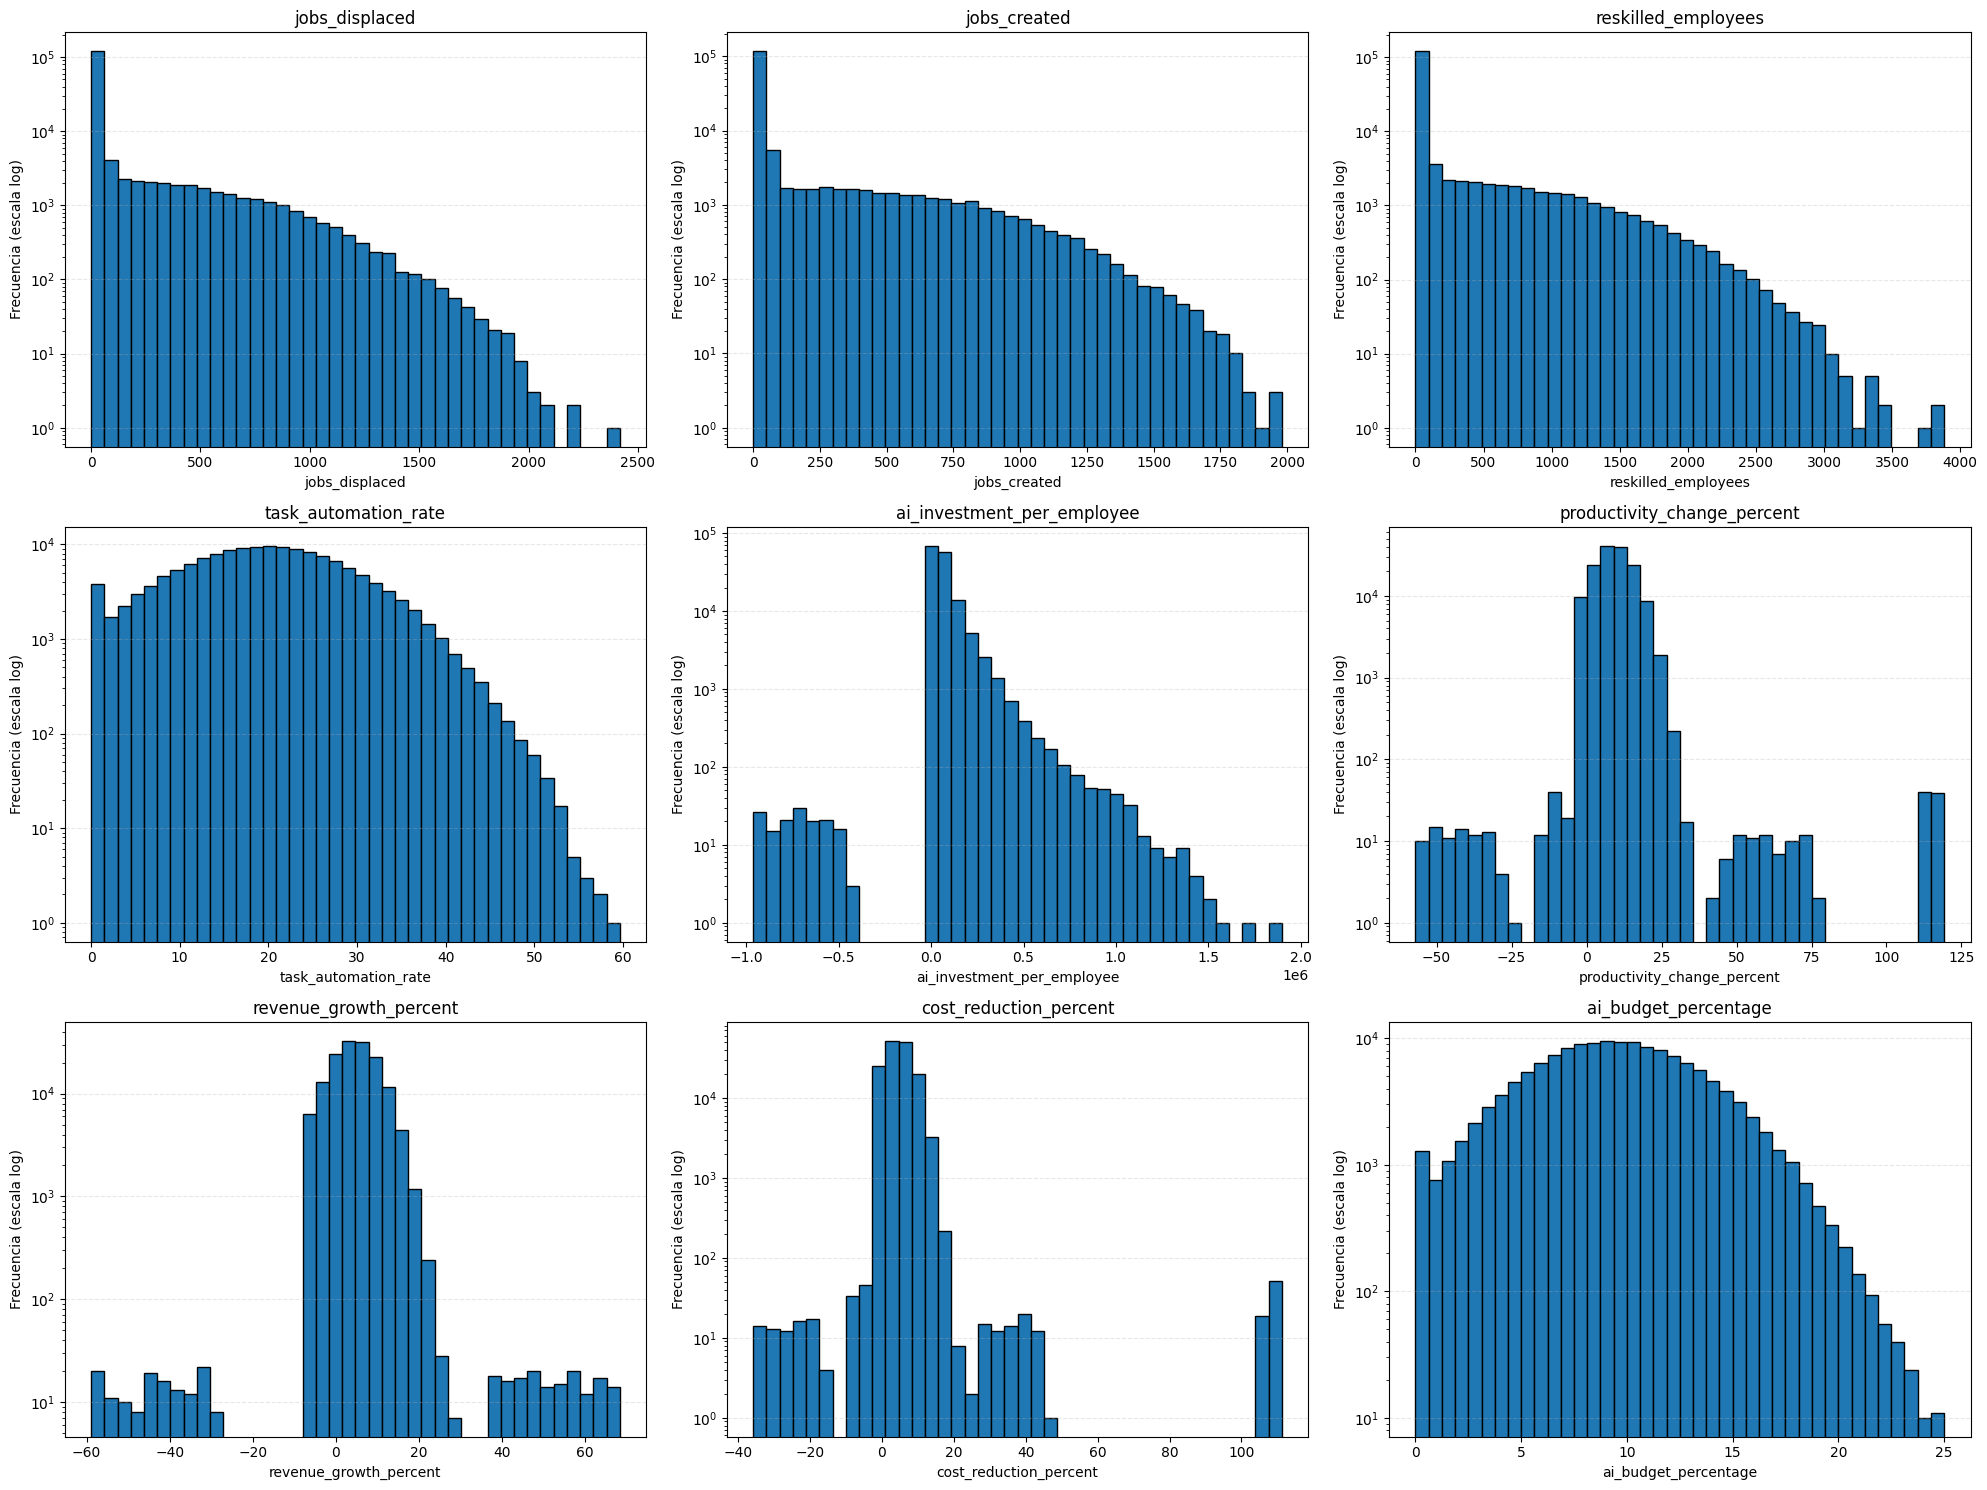

In [6]:
# Graficamos para ver la distribucion de las variables relacionadas a las preguntas de investigacion
# Usamos escala logaritmica en el eje Y porque varias de estas variables son muy asimetricas a la
# derecha (jobs_displaced tiene mediana 10 y maximo 2417): en escala lineal la primera barra aplasta
# visualmente al resto y no se alcanza a ver la forma de la cola.

variables = ["jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate",
             "ai_investment_per_employee", "productivity_change_percent",
             "revenue_growth_percent", "cost_reduction_percent", "ai_budget_percentage"]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].hist(df1[var].dropna(), bins=40, edgecolor='black')
    axes[i].set_yscale('log')
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia (escala log)')
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [7]:
# Exploramos los estadisticos de las variables

variables = ["jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate",
             "ai_investment_per_employee", "productivity_change_percent",
             "revenue_growth_percent", "cost_reduction_percent", "ai_budget_percentage"]

resumen = pd.DataFrame({
    "count": df1[variables].count(),
    "nulos": df1[variables].isnull().sum(),
    "media": df1[variables].mean(),
    "mediana": df1[variables].median(),
    "desvio_std": df1[variables].std(),
    "min": df1[variables].min(),
    "max": df1[variables].max(),
    "q1": df1[variables].quantile(0.25),
    "q3": df1[variables].quantile(0.75),
    "asimetria": df1[variables].skew(),
    "curtosis": df1[variables].kurt(),
})

resumen = resumen.round(2)
resumen

,count,nulos,media,mediana,desvio_std,min,max,q1,q3,asimetria,curtosis
jobs_displaced,150025,0,111.37,10.00,255.86,0.00,2417.00,2.00,41.00,3.03,9.63
jobs_created,150025,0,117.88,12.00,261.66,0.00,1980.00,3.00,41.00,2.79,7.64
reskilled_employees,150025,0,181.64,16.00,417.94,0.00,3881.00,3.00,64.00,2.99,9.21
task_automation_rate,150025,0,19.76,19.70,9.22,0.00,59.63,13.36,26.02,0.11,-0.23
ai_investment_per_employee,150025,0,68684.13,43248.25,92802.06,-962812.21,1898315.75,21259.76,81718.90,3.35,35.43
productivity_change_percent,150025,0,9.31,9.06,6.37,-57.05,119.20,5.06,13.13,2.55,43.61
revenue_growth_percent,147778,2247,4.62,4.48,5.74,-58.91,68.32,0.77,8.25,0.26,10.63
cost_reduction_percent,150024,1,4.86,4.62,4.19,-35.69,111.23,2.11,7.13,7.41,180.18
ai_budget_percentage,147775,2250,9.51,9.43,3.84,0.00,25.00,6.88,12.08,0.12,-0.10


**Interpretación**

Las variables relacionadas al impacto laboral (jobs_displaced, jobs_created, reskilled_employees) muestran un patrón similar: distribuciones fuertemente asimétricas a la derecha (asimetría entre 2.8 y 3.0), con una moda muy marcada en 0 y una cola larga de valores extremos que llega hasta los miles. La media en los tres casos está muy por encima de la mediana (por ejemplo, en jobs_displaced la media es 111.37 contra una mediana de apenas 10), lo que confirma que un grupo reducido de empresas con valores muy altos está inflando el promedio general. Entre las tres, reskilled_employees presenta los valores más elevados de media y mediana, sugiriendo que, al menos en términos absolutos.

task_automation_rate se comporta de forma distinta: su asimetría (0.11) y curtosis (-0.23) cercanas a 0 indican una distribución aproximadamente simétrica, similar a una normal, con un leve exceso de casos en 0 (empresas sin automatización de tareas).

En cuanto a las variables de inversión y retorno, ai_budget_percentage también muestra una distribución cercana a la simetría (asimetría 0.12), mientras que ai_investment_per_employee es la más problemática del grupo: asimetría de 3.35 y curtosis de 35.43, y valor negativos que no tienen un sentido economico claro.

Por último, productivity_change_percent, revenue_growth_percent y especialmente cost_reduction_percent muestran el mismo patrón: una distribución que a simple vista parece cercana a una normal centrada en valores positivos moderados, pero con curtosis extremadamente alta (43.61, 10.63 y 180.18 respectivamente), lo que indica la presencia de outliers muy alejados del centro que comprimen visualmente el grueso de la distribución. El caso de cost_reduction_percent es el más extremo: una curtosis de 180 es un indicador muy fuerte de valores atípicos que deberían tratarse antes de cualquier análisis bivariado o modelado posterior.


## 2.3 Contexto geográfico: indicadores por país

Distribución de los indicadores de `country_ai_index` (`df3`) sobre el mapa, para ver cómo se reparten geográficamente el desarrollo digital, la capacidad de IA y la política regulatoria.

In [8]:
# --- Fix de nombres de país ---
df3["country"] = df3["country"].replace({"USA": "United States", "UK": "United Kingdom"})

variables_geo = ["gdp_per_capita", "internet_penetration", "digital_maturity_index",
                  "ai_patent_filings_2024", "ai_researchers_per_million"]

titulos = ["PBI per cápita", "Penetración de Internet (%)", "Índice de madurez digital",
           "Patentes de IA (2024)", "Investigadores en IA por millón", "Política de IA"]

orden_politica = {"Lenient": 0, "Moderate": 1, "Strict": 2}
df3["policy_code"] = df3["country_ai_policy"].map(orden_politica)

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}]*3, [{"type": "choropleth"}]*3],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (1,3), (2,1), (2,2)]

# --- 5 mapas numéricos, sin barra individual ---
for (var, titulo, pos) in zip(variables_geo, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=df3["country"],
        locationmode="country names",
        z=df3[var],
        colorscale="YlOrRd",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

# --- Barra genérica: punto invisible con la misma escala de color, solo para mostrar el gradiente ---
barra_generica = go.Scattergeo(
    lon=[0], lat=[0],
    mode="markers",
    marker=dict(
        size=0.001,
        color=[0.5],
        colorscale="YlOrRd",
        cmin=0, cmax=1,
        showscale=True,
        colorbar=dict(
            title=dict(text="Nivel del<br>indicador", side="top", font=dict(size=11)),
            tickvals=[0, 1],
            ticktext=["Menor", "Mayor"],
            thickness=15,
            len=0.5,
            x=1.03,
            y=0.78
        )
    ),
    showlegend=False,
    hoverinfo="skip"
)
fig.add_trace(barra_generica, row=1, col=1)

# --- 6to mapa: política de IA (categórica), con su propia colorbar ---
choropleth_policy = go.Choropleth(
    locations=df3["country"],
    locationmode="country names",
    z=df3["policy_code"],
    colorscale=[[0, "#a1d99b"], [0.5, "#fdae61"], [1, "#d73027"]],
    zmin=0, zmax=2,
    colorbar=dict(
        title=dict(text="Política de IA", side="top", font=dict(size=11)),
        tickvals=[0, 1, 2],
        ticktext=["Lenient", "Moderate", "Strict"],
        thickness=15,
        len=0.4,
        x=1.03,
        y=0.2
    ),
    showscale=True,
    name="Política de IA"
)
fig.add_trace(choropleth_policy, row=2, col=3)

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1500, title_text="Contexto geográfico de indicadores de IA")
fig.show()

**Interpretación**

Los indicadores de desarrollo digital y capacidad de IA muestran una concentración geográfica clara: Norteamérica, Europa occidental, el este asiático (Japón, Corea del Sur) y Oceanía lideran de forma consistente en PBI per cápita, penetración de internet, índice de madurez digital e investigadores en IA por millón. En el otro extremo, África y gran parte de Asia del sur/sudeste (India, Indonesia, Vietnam, Filipinas) muestran los valores más bajos en casi todas las dimensiones, con Europa del este (Polonia) y Sudamérica ubicadas en un nivel intermedio.

El mapa de patentes de IA (2024) rompe parcialmente este patrón: China se destaca con un volumen de patentes comparable al de Estados Unidos, pese a tener un PBI per cápita considerablemente menor que el resto de los países que lideran las otras métricas. Esto sugiere que la producción de innovación en IA no depende exclusivamente de la riqueza del país, sino que puede estar impulsada por otros factores (política industrial, tamaño de la población, inversión estatal dirigida).

En cuanto a política regulatoria, no se observa una relación directa y simple con el nivel de desarrollo: países con alto desarrollo digital aplican tanto políticas estrictas (Alemania, Países Bajos, Suecia, Japón, Corea del Sur) como moderadas (Estados Unidos, Reino Unido, Canadá, Australia), mientras que las políticas "lenientes" se concentran mayormente en países con menor desarrollo digital (India, Indonesia, Vietnam, Filipinas, Nigeria, Kenia). El caso de China es particularmente notable: combina una política estricta con uno de los niveles más altos de producción de patentes, lo que cuestiona la idea de que mayor regulación necesariamente frena la innovación en IA.

## 2.4 Estructura de la variación: entre empresas vs. dentro de cada empresa

Antes de pasar al análisis bivariado se descompone la varianza de cada variable en dos partes: la que se explica por diferencias **entre** empresas y la que corresponde a la fluctuación **dentro** de cada empresa a lo largo de los trimestres. El resultado define a qué nivel conviene trabajar en la sección 3.

In [9]:
variables_a_chequear = [
    "ai_budget_percentage", "ai_investment_per_employee",
    "productivity_change_percent", "revenue_growth_percent", "cost_reduction_percent",
    "jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate"
]

resultados = []

for var in variables_a_chequear:
    # Varianza total (todas las filas, todas las empresas, todos los trimestres)
    var_total = df1[var].var()

    # Varianza "entre" empresas: variación de los promedios de cada empresa
    medias_por_empresa = df1.groupby("company_id")[var].mean()
    var_entre = medias_por_empresa.var()

    # Varianza "dentro" de empresa: promedio de la varianza de cada empresa a lo largo de sus trimestres
    var_dentro = df1.groupby("company_id")[var].var().mean()

    # Proporción de la varianza total que es "ruido" dentro de empresa
    pct_dentro = var_dentro / (var_dentro + var_entre) * 100

    resultados.append({
        "variable": var,
        "var_entre_empresas": round(var_entre, 2),
        "var_dentro_empresa": round(var_dentro, 2),
        "%_variacion_dentro": round(pct_dentro, 1)
    })

tabla_varianza = pd.DataFrame(resultados).sort_values("%_variacion_dentro", ascending=False)
tabla_varianza

,variable,var_entre_empresas,var_dentro_empresa,%_variacion_dentro
4,cost_reduction_percent,2.340000e+00,1.656000e+01,87.6
3,revenue_growth_percent,5.080000e+00,3.040000e+01,85.7
2,productivity_change_percent,1.141000e+01,3.207000e+01,73.7
8,task_automation_rate,2.687000e+01,6.256000e+01,70.0
0,ai_budget_percentage,6.260000e+00,9.100000e+00,59.2
1,ai_investment_per_employee,6.652363e+09,2.211817e+09,25.0
5,jobs_displaced,5.599653e+04,1.050582e+04,15.8
7,reskilled_employees,1.493187e+05,2.771555e+04,15.7
6,jobs_created,6.338864e+04,5.644570e+03,8.2


**Interpretación y decisión metodológica**

Se decidió agregar el análisis a nivel empresa, dado que las variables de resultado económico (productividad, ingresos, reducción de costos) presentan entre 70% y 88% de su variación total dentro de cada empresa a lo largo de los trimestres, lo cual indica que gran parte de la dispersión observada a nivel encuesta responde a fluctuación de corto plazo más que a diferencias estructurales entre empresas. En contraste, las variables de impacto laboral (empleos creados, desplazados, reentrenados) muestran una proporción baja de variación interna (8%-16%), lo cual sugiere que sus diferencias reflejan principalmente heterogeneidad estructural entre empresas, y no ruido temporal.

<a id="3"></a>

---

# 3. Análisis bivariado y comparaciones

> **Consigna**
> Elegí al menos 3 comparaciones o relaciones entre variables. Algunos ejes posibles (no son obligatorios, son disparadores):
> - Adopción de IA por industria o tipo de empresa
> - Relación entre inversión en IA y cambios en productividad o empleo
> - Diferencias entre países o regiones
> - Cualquier relación que les parezca interesante explorar
>
> Para cada análisis: mostrá la visualización y escribí una interpretación. No alcanza con el gráfico solo.

Se desarrollan **tres comparaciones**, cada una con su visualización, su corte por industria y por país, y su interpretación escrita:

1. **Perfil de las industrias** según indicadores de adopción, madurez, fallas y empleo (§ 3.1)
2. **Inversión en IA vs. retorno económico**: presupuesto contra productividad, costos e ingresos (§ 3.3)
3. **Automatización vs. impacto en la fuerza laboral**: empleos desplazados, creados y reentrenados (§ 3.4)

## 3.1 Comparación 1 — Perfil de las industrias según indicadores de IA

Se cruzan siete métricas de `ai_industry_summary` (`df2`) contra la industria. Los valores se normalizan a 0–1 por columna para que métricas de escalas muy distintas (ej. `avg_jobs_displaced` ~100 vs. `avg_ai_maturity_score` ~0.3) pesen igual en el color; las anotaciones muestran el valor real.

A continuación se agregan los estadísticos generales de las mismas variables sobre `df1` completo, como línea de base contra la cual leer el heatmap.

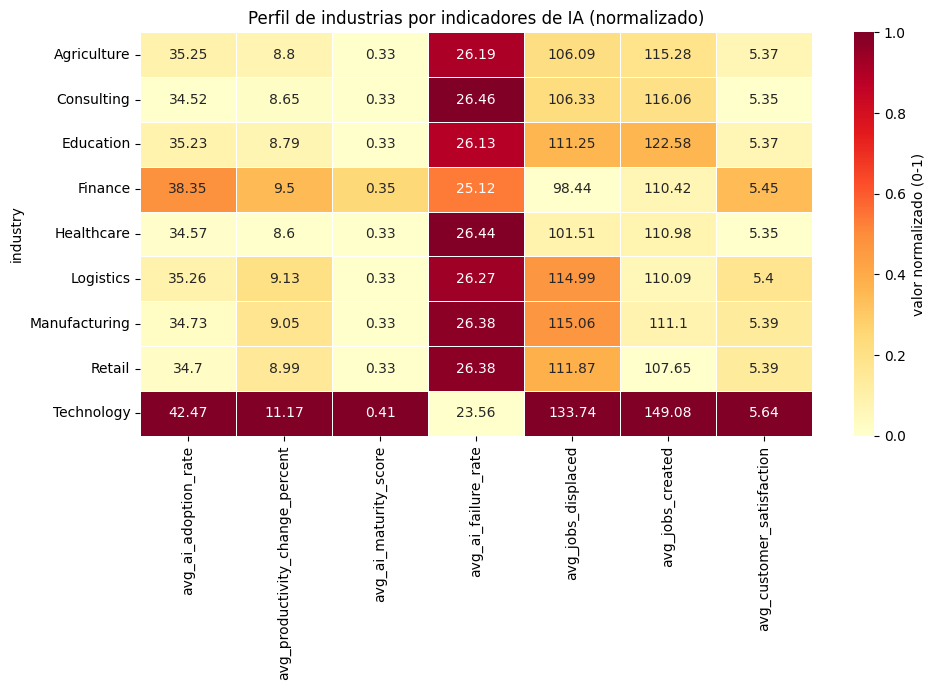

In [10]:
metricas = ["avg_ai_adoption_rate", "avg_productivity_change_percent", "avg_ai_maturity_score",
            "avg_ai_failure_rate", "avg_jobs_displaced", "avg_jobs_created", "avg_customer_satisfaction"]

# Armamos la matriz con industry como índice
heat_data = df2.set_index("industry")[metricas]

# Normalizamos cada columna (0 a 1) para que todas las métricas pesen igual
# pese a tener escalas muy distintas (ej: avg_jobs_displaced ~100 vs avg_ai_maturity_score ~0.3)
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

plt.figure(figsize=(10, 7))
sns.heatmap(heat_norm, annot=heat_data.round(2), fmt="", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "valor normalizado (0-1)"})
plt.title("Perfil de industrias por indicadores de IA (normalizado)")
plt.tight_layout()
plt.show()

In [11]:
variables_comparar = ["ai_adoption_rate", "productivity_change_percent", "ai_maturity_score",
                       "ai_failure_rate", "jobs_displaced", "jobs_created", "customer_satisfaction"]

# --- Estadísticos generales (todo df1, sin agrupar) ---
resumen_general = pd.DataFrame({
    "media": df1[variables_comparar].mean(),
    "mediana": df1[variables_comparar].median(),
    "desvio_std": df1[variables_comparar].std(),
    "min": df1[variables_comparar].min(),
    "max": df1[variables_comparar].max(),
    "nulos": df1[variables_comparar].isnull().sum(),
}).round(2)

print("=== Estadísticos generales (df1 completo) ===")
resumen_general

=== Estadísticos generales (df1 completo) ===


,media,mediana,desvio_std,min,max,nulos
ai_adoption_rate,36.43,36.33,15.42,-138.00,210.12,2249
productivity_change_percent,9.31,9.06,6.37,-57.05,119.20,0
ai_maturity_score,0.34,0.34,0.13,0.00,0.90,0
ai_failure_rate,25.77,25.88,7.76,0.00,40.00,0
jobs_displaced,111.37,10.00,255.86,0.00,2417.00,0
jobs_created,117.88,12.00,261.66,0.00,1980.00,0
customer_satisfaction,5.42,5.41,1.05,1.00,9.76,2252


**Interpretación**

 Technology se distingue claramente del resto en casi todas las dimensiones, con los valores más altos de adopción de IA (42.47%), cambio en productividad (11.17%), madurez de IA (0.41) y satisfacción del cliente (5.64), además de ser la única industria con avg_ai_failure_rate visiblemente por debajo del resto (23.56 vs. valores entre 25 y 26.5 en las demás). Esto sugiere que, en este dataset, mayor adopción y madurez de IA se asocian con menor tasa de fallas, en vez de con más riesgo operativo.

Las otras ocho industrias muestran un perfil bastante homogéneo entre sí: tasas de adopción similares (34.5%-35.3%, con la excepción de Finance en 38.35%) y tasas de fallas casi idénticas (~26%-26.5%). Donde sí aparece algo de variación es en los indicadores de empleo: Manufacturing y Logistics presentan los avg_jobs_displaced más altos del grupo (115.06 y 114.99), mientras que Finance tiene el más bajo (98.44). En cuanto a creación de empleo, Education se destaca dentro de este grupo homogéneo (122.58), superando incluso a industrias con mayor desplazamiento.

Vale la pena notar que Technology no solo lidera en desplazamiento de empleos (133.74) sino también en creación (149.08), con la diferencia más amplia a favor de la creación entre todas las industrias — un patrón que conviene tener presente al momento de plantear hipótesis sobre destrucción neta de empleo.
Sin embargo hay que tener en cuenta que para las variables de empleos destruidos y creados, la mediana no es el mejor estadistico dada la distribucion asimetrica que presentan estas variables.

## 3.2 Preparación — Agregación a nivel empresa

Siguiendo la conclusión de § 2.4, se colapsa `df1` a una fila por empresa promediando sus trimestres. Esto elimina la fluctuación de corto plazo de las variables económicas y deja la heterogeneidad estructural entre empresas, que es lo que interesa comparar. Se agrega además `jobs_net_balance` (empleos creados menos desplazados).

In [12]:
df_empresa = df1.groupby("company_id").agg(
    ai_budget_percentage=("ai_budget_percentage", "mean"),
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    industry=("industry", "first"),
    country=("country", "first"),
    region=("region", "first"),
    company_size=("company_size", "first"),
).reset_index()

df_empresa["jobs_net_balance"] = df_empresa["jobs_created"] - df_empresa["jobs_displaced"]



## 3.3 Comparación 2 — Inversión en IA vs. retorno económico

¿Es rentable invertir en IA? Se cruza `ai_budget_percentage` contra los tres indicadores de retorno (productividad, reducción de costos, crecimiento de ingresos) y contra la inversión por empleado, primero con dispersión y correlaciones, y después desagregado por industria y por país.

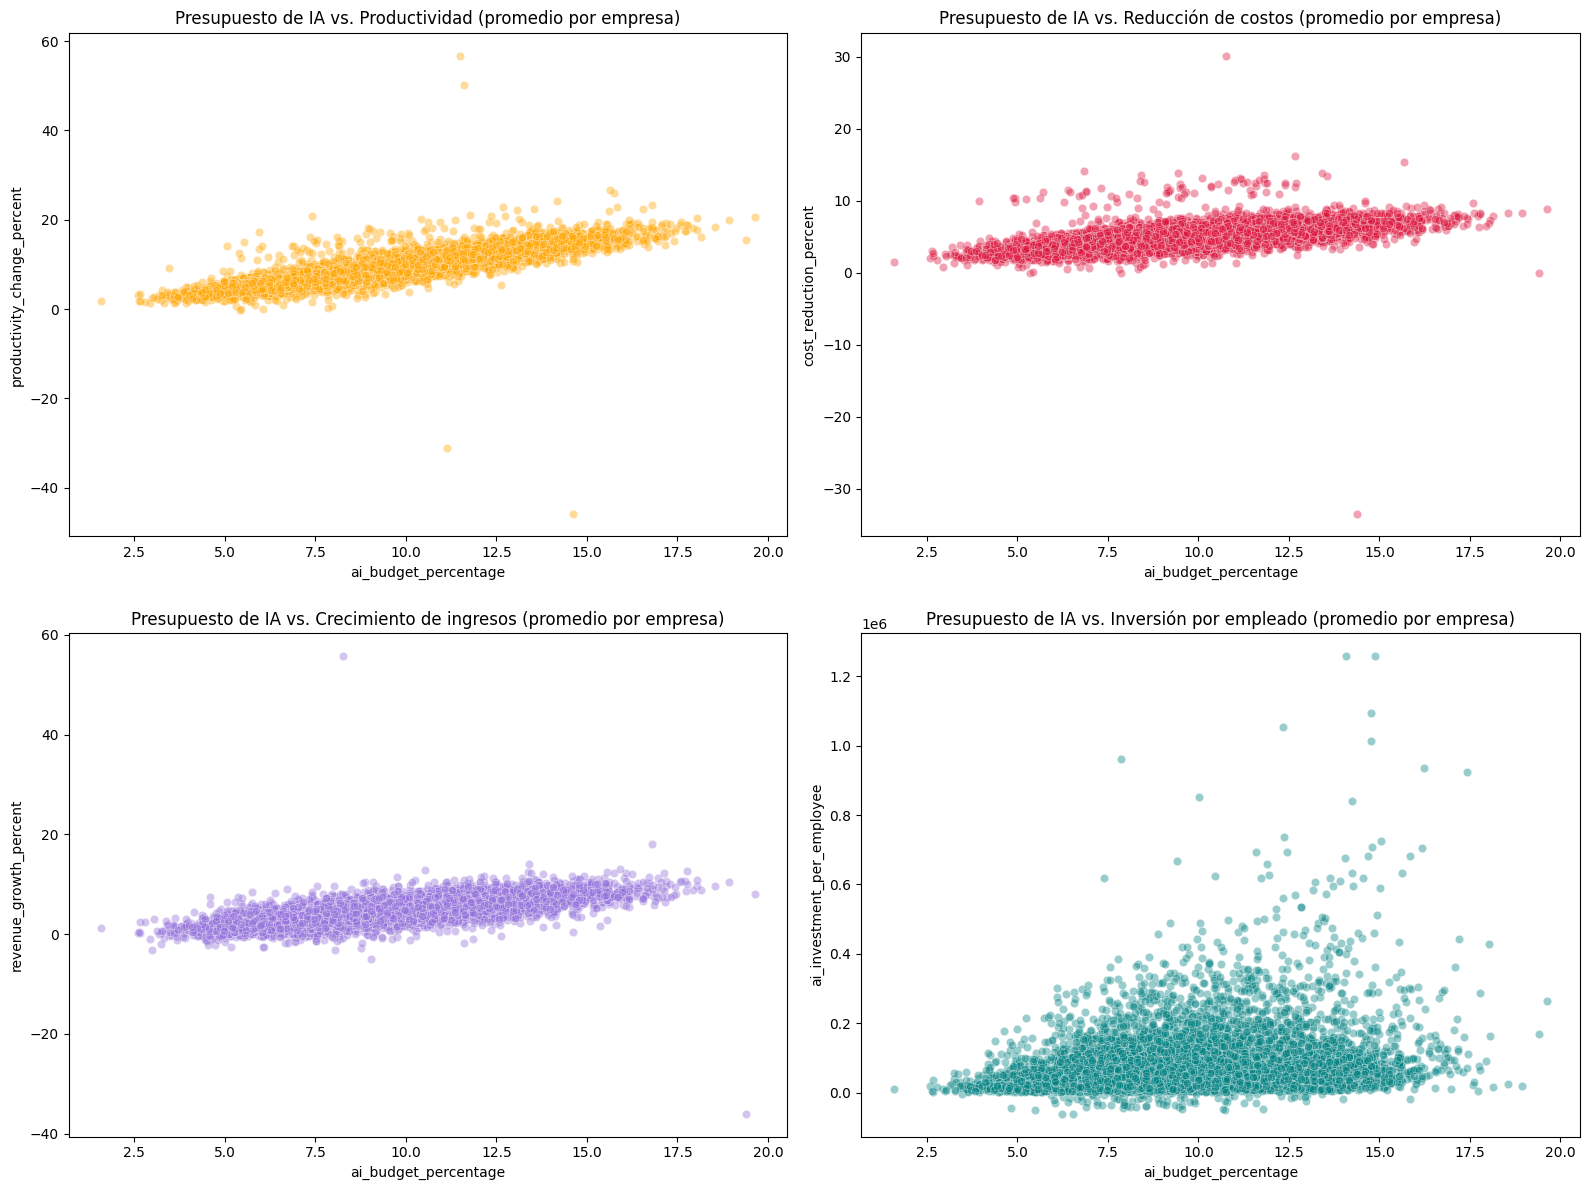

ai_budget_percentage vs productivity_change_percent: 0.838
ai_budget_percentage vs cost_reduction_percent: 0.603
ai_budget_percentage vs revenue_growth_percent: 0.675
ai_budget_percentage vs ai_investment_per_employee: 0.271


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# --- 1. Presupuesto vs Productividad ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="productivity_change_percent",
                 alpha=0.4, color="orange", ax=axes[0])
axes[0].set_title("Presupuesto de IA vs. Productividad (promedio por empresa)")
axes[0].set_xlabel("ai_budget_percentage")
axes[0].set_ylabel("productivity_change_percent")

# --- 2. Presupuesto vs Reducción de costos ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="cost_reduction_percent",
                 alpha=0.4, color="crimson", ax=axes[1])
axes[1].set_title("Presupuesto de IA vs. Reducción de costos (promedio por empresa)")
axes[1].set_xlabel("ai_budget_percentage")
axes[1].set_ylabel("cost_reduction_percent")

# --- 3. Presupuesto vs Crecimiento de ingresos ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="revenue_growth_percent",
                 alpha=0.4, color="mediumpurple", ax=axes[2])
axes[2].set_title("Presupuesto de IA vs. Crecimiento de ingresos (promedio por empresa)")
axes[2].set_xlabel("ai_budget_percentage")
axes[2].set_ylabel("revenue_growth_percent")

# --- 4. Presupuesto vs Inversión por empleado ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="ai_investment_per_employee",
                 alpha=0.4, color="teal", ax=axes[3])
axes[3].set_title("Presupuesto de IA vs. Inversión por empleado (promedio por empresa)")
axes[3].set_xlabel("ai_budget_percentage")
axes[3].set_ylabel("ai_investment_per_employee")

plt.tight_layout()
plt.show()

# --- Correlaciones de los 4 cruces ---
pares = [
    ("ai_budget_percentage", "productivity_change_percent"),
    ("ai_budget_percentage", "cost_reduction_percent"),
    ("ai_budget_percentage", "revenue_growth_percent"),
    ("ai_budget_percentage", "ai_investment_per_employee"),
]

for x, y in pares:
    corr = df_empresa[[x, y]].corr().iloc[0,1]
    print(f"{x} vs {y}: {corr:.3f}")

**Desagregado por industria**

In [14]:
resumen_industria_4vars = df_empresa.groupby("industry").agg(
    ai_budget_percentage=("ai_budget_percentage", "mean"),
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    n_empresas=("company_id", "count")
).reset_index().sort_values("ai_budget_percentage", ascending=False)

resumen_industria_4vars.round(2)

resumen_industria_4vars.round(2).style.background_gradient(
    cmap="YlOrRd", subset=["ai_budget_percentage", "productivity_change_percent",
                            "cost_reduction_percent", "revenue_growth_percent",
                            "ai_investment_per_employee"]
)

,industry,ai_budget_percentage,productivity_change_percent,cost_reduction_percent,revenue_growth_percent,ai_investment_per_employee,n_empresas
8,Technology,12.200000,11.170000,5.370000,5.580000,86495.660000,1411
3,Finance,9.570000,9.560000,4.890000,4.860000,70321.030000,1346
0,Agriculture,9.050000,8.860000,4.590000,4.370000,65077.300000,1039
2,Education,9.040000,8.870000,4.550000,4.310000,67839.470000,1015
5,Logistics,9.020000,9.160000,5.030000,4.540000,66908.360000,867
6,Manufacturing,8.990000,9.070000,4.920000,4.450000,63271.250000,1172
4,Healthcare,8.940000,8.630000,4.620000,4.230000,66247.080000,1243
1,Consulting,8.930000,8.700000,4.540000,4.330000,62417.460000,834
7,Retail,8.930000,9.050000,5.040000,4.500000,63726.680000,1095


**Desagregado por país**

In [15]:


# --- Agregamos por país las 4 variables ---
resumen_pais_4vars = df_empresa.groupby("country").agg(
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    n_empresas=("company_id", "count")
).reset_index()

# --- Fix de nombres de país ---
resumen_pais_4vars["country"] = resumen_pais_4vars["country"].replace(
    {"USA": "United States", "UK": "United Kingdom"}
)

variables_mapa = ["productivity_change_percent", "cost_reduction_percent",
                   "revenue_growth_percent", "ai_investment_per_employee"]

titulos = ["Cambio en productividad", "Reducción de costos",
           "Crecimiento de ingresos", "Inversión en IA por empleado"]

# --- Armado de la grilla 2x2 ---
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}],
           [{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (2,1), (2,2)]

for (var, titulo, pos) in zip(variables_mapa, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=resumen_pais_4vars["country"],
        locationmode="country names",
        z=resumen_pais_4vars[var],
        colorscale="YlOrRd",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1400, title_text="Indicadores económicos de IA por país (agregado por empresa)")
fig.show()

**Interpretación**

El análisis exploratorio muestra una asociación positiva entre el presupuesto destinado a IA y los tres indicadores de retorno considerados: cambio en productividad, reducción de costos y crecimiento de ingresos. Esta relación deberá confirmarse con pruebas estadísticas en instancias posteriores, pero la tendencia visual es consistente en los tres casos.

A nivel industria, el sector tecnológico lidera de forma clara en las tres métricas de retorno, seguido a cierta distancia por el sector financiero. La única excepción parcial aparece en reducción de costos, donde logística, retail y manufactura se acercan más al desempeño de Technology que en las otras dos métricas, aunque sin superarlo.

A nivel geográfico, se observa una tendencia predominante donde los países con mayor PBI per cápita obtienen mejores resultados en productividad, reducción de costos y crecimiento de ingresos — replicando el patrón ya identificado en el contexto general de desarrollo digital. La excepción más notable es India, que muestra la inversión en IA por empleado más alta pese a no liderar en productividad ni en las demás métricas de retorno. Esta observación amerita revisión adicional, dado que la variable de inversión por empleado todavía contiene valores atípicos sin depurar (incluyendo montos negativos) y no se verificó si el resultado se sostiene con una muestra suficiente de empresas para ese país.


## 3.4 Comparación 3 — Automatización e impacto en la fuerza laboral

¿La IA destruye trabajos? Se cruza la tasa de automatización contra los empleos desplazados, y los desplazados contra los creados y los reentrenados. Se comparan además las correlaciones a nivel encuesta y a nivel empresa, y se desagrega por industria y por país.

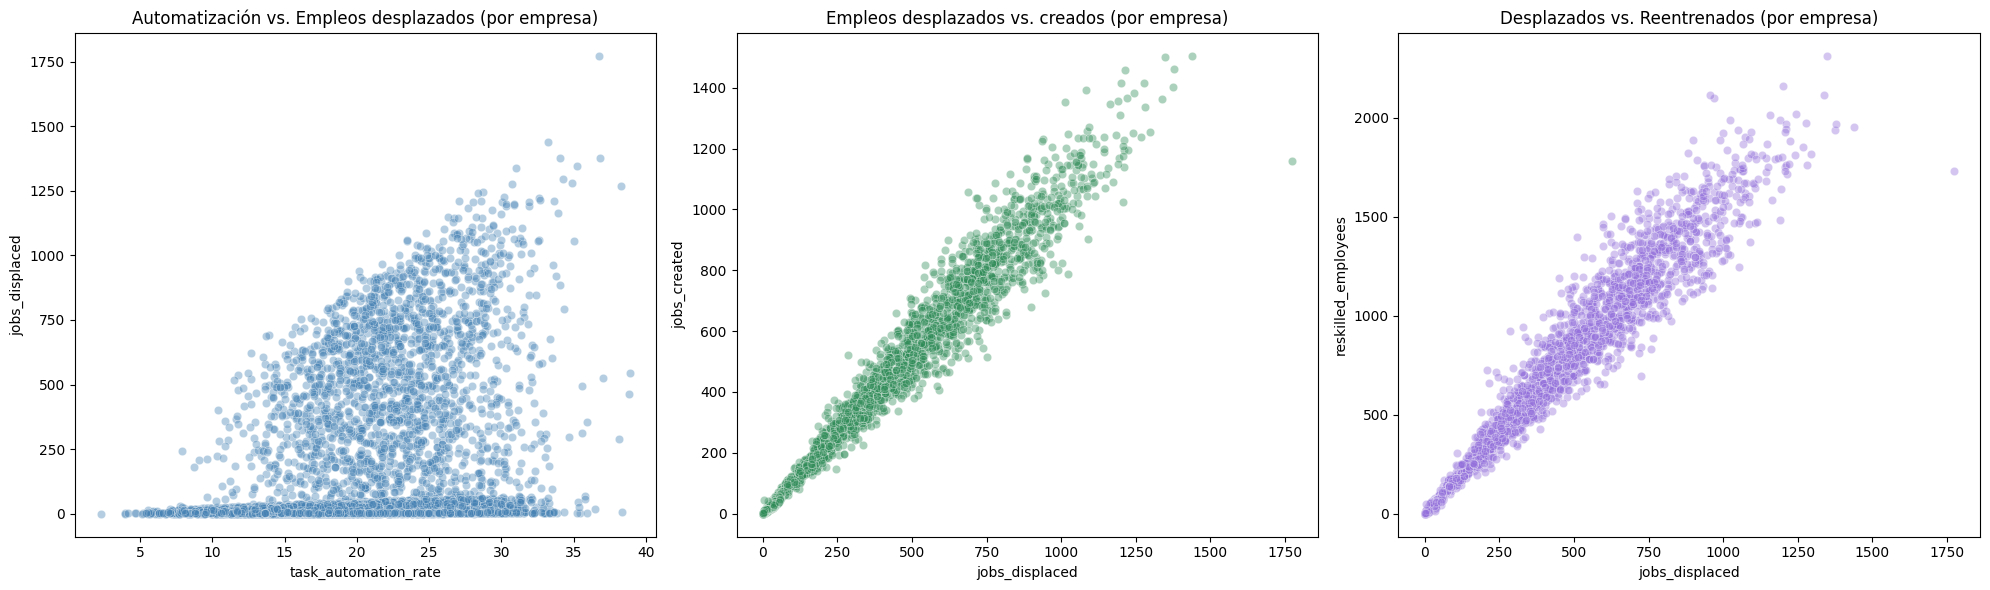

task_automation_rate vs jobs_displaced: encuesta=0.286 | empresa=0.317
jobs_displaced vs jobs_created: encuesta=0.924 | empresa=0.991
jobs_displaced vs reskilled_employees: encuesta=0.877 | empresa=0.988


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(data=df_empresa, x="task_automation_rate", y="jobs_displaced",
                 alpha=0.4, color="steelblue", ax=axes[0])
axes[0].set_title("Automatización vs. Empleos desplazados (por empresa)")

sns.scatterplot(data=df_empresa, x="jobs_displaced", y="jobs_created",
                 alpha=0.4, color="seagreen", ax=axes[1])
axes[1].set_title("Empleos desplazados vs. creados (por empresa)")

sns.scatterplot(data=df_empresa, x="jobs_displaced", y="reskilled_employees",
                 alpha=0.4, color="mediumpurple", ax=axes[2])
axes[2].set_title("Desplazados vs. Reentrenados (por empresa)")

plt.tight_layout()
plt.show()

# --- Comparación de correlaciones: encuesta vs. empresa ---
pares = [
    ("task_automation_rate", "jobs_displaced"),
    ("jobs_displaced", "jobs_created"),
    ("jobs_displaced", "reskilled_employees"),
]

for x, y in pares:
    corr_original = df1[[x, y]].corr().iloc[0,1]
    corr_agregado = df_empresa[[x, y]].corr().iloc[0,1]
    print(f"{x} vs {y}: encuesta={corr_original:.3f} | empresa={corr_agregado:.3f}")

**Desagregado por industria**

In [17]:
resumen_industria_empleo = df_empresa.groupby("industry").agg(
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    jobs_net_balance=("jobs_net_balance", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    n_empresas=("company_id", "count")
).reset_index().sort_values("jobs_net_balance", ascending=False)



resumen_industria_empleo.round(2)

resumen_industria_empleo.round(2).style.background_gradient(
    cmap="YlGnBu", subset=["jobs_displaced", "jobs_created", "reskilled_employees",
                            "jobs_net_balance", "task_automation_rate"]
)

,industry,jobs_displaced,jobs_created,reskilled_employees,jobs_net_balance,task_automation_rate,n_empresas
8,Technology,134.800000,149.740000,224.580000,14.940000,21.600000,1411
3,Finance,99.430000,111.460000,171.160000,12.030000,19.690000,1346
2,Education,111.310000,122.850000,192.830000,11.540000,18.180000,1015
1,Consulting,106.040000,115.750000,180.660000,9.710000,18.060000,834
4,Healthcare,101.500000,110.890000,171.420000,9.380000,18.100000,1243
0,Agriculture,106.200000,115.480000,177.910000,9.280000,18.370000,1039
6,Manufacturing,115.050000,111.120000,172.680000,-3.920000,21.050000,1172
7,Retail,111.350000,107.200000,167.430000,-4.160000,21.030000,1095
5,Logistics,114.720000,109.730000,168.290000,-4.980000,21.240000,867


**Desagregado por país**

In [18]:
# Analizamos el contexto geografico para ver si influye de alguna manera en como se comportan estas variables

resumen_pais_empleo = df_empresa.groupby("country").agg(
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    jobs_net_balance=("jobs_net_balance", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    n_empresas=("company_id", "count")
).reset_index()

resumen_pais_empleo["country"] = resumen_pais_empleo["country"].replace(
    {"USA": "United States", "UK": "United Kingdom"}
)

variables_mapa = ["jobs_displaced", "jobs_created", "reskilled_employees",
                   "jobs_net_balance", "task_automation_rate"]
titulos = ["Empleos desplazados", "Empleos creados", "Empleados reentrenados",
           "Saldo neto de empleo", "Tasa de automatización"]

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}]*3, [{"type": "choropleth"}]*3],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (1,3), (2,1), (2,2)]

for (var, titulo, pos) in zip(variables_mapa, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=resumen_pais_empleo["country"],
        locationmode="country names",
        z=resumen_pais_empleo[var],
        colorscale="YlGnBu",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

# --- Barra genérica: punto invisible con la misma escala de color, solo para mostrar el gradiente ---
barra_generica = go.Scattergeo(
    lon=[0], lat=[0],
    mode="markers",
    marker=dict(
        size=0.001,
        color=[0.5],
        colorscale="YlGnBu",
        cmin=0, cmax=1,
        showscale=True,
        colorbar=dict(
            title=dict(text="Nivel del<br>indicador", side="top", font=dict(size=11)),
            tickvals=[0, 1],
            ticktext=["Menor", "Mayor"],
            thickness=15,
            len=0.5,
            x=1.02,
            y=0.2   # a la altura de la fila 2, aprovechando el espacio vacío de esa fila
        )
    ),
    showlegend=False,
    hoverinfo="skip"
)
fig.add_trace(barra_generica, row=2, col=2)

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1400, title_text="Indicadores de empleo por país (agregado por empresa)")
fig.show()

**Interpretación**

 Si bien Technology vuelve a liderar en saldo neto de empleo (14.94) y en cantidad de empleados reentrenados (224.58, notablemente por encima del resto), no es la única industria con resultado favorable: Finance, Education, Consulting, Healthcare y Agriculture también muestran saldo neto positivo, formando un grupo de industrias más orientadas a servicios y conocimiento. En contraste, Manufacturing, Retail y Logistics son las únicas con saldo neto negativo, pese a tener tasas de automatización similares o incluso superiores a algunas del primer grupo. Esta disociación entre automatización y resultado neto de empleo es consistente con el patrón identificado previamente en el análisis bivariado (relación tipo "cono", donde la automatización habilita pero no determina el desplazamiento): a nivel industria, se observa que automatización alta puede coexistir tanto con saldo positivo (Technology) como negativo (Manufacturing, Retail, Logistics), lo que sugiere que el tipo de tareas automatizadas —más que el volumen de automatización en sí— podría ser el factor que explica si el resultado neto es favorable o no.

A nivel geográfico, los mapas muestran patrones similares a los observados en el contexto de desarrollo digital general, con Norteamérica, Europa occidental y Oceanía destacándose en la mayoría de los indicadores. Es importante señalar, sin embargo, que las variables de empleo utilizadas aquí son conteos absolutos (cantidad de personas) y no están normalizadas por el tamaño promedio de empresa en cada país, por lo que las diferencias observadas entre países podrían reflejar en parte variaciones en la composición de la muestra (empresas más grandes en algunos países) más que diferencias reales en la intensidad del impacto de la IA sobre el empleo. Esta limitación queda anotada como punto a resolver en instancias posteriores del análisis, normalizando estas variables por num_employees antes de comparar entre países.


<a id="4"></a>

---

# 4. Hipótesis de investigación

> **Consigna**
> Formulá al menos 2 preguntas o hipótesis propias que hayan surgido de la exploración. Para cada una:
> - Enunciá la pregunta con claridad
> - Explicá qué observaron en los datos que los llevó a formularla
> - Pensá cómo la responderían técnicamente en los prácticos siguientes

## Hipótesis 1 — Retorno económico de la inversión en IA

**Pregunta**

> Es posible predecir el crecimiento de los ingresos de una empresa en base al porcentaje de presupuesta que destina para IA?

**Qué observamos que la motiva**

En § 3.3 la relación entre `ai_budget_percentage` y los tres indicadores de retorno (productividad, reducción de costos y crecimiento de ingresos) es positiva y consistente en los tres cruces. En § 3.1 el patrón se repite a nivel industria: Technology lidera las tres métricas de retorno y es además la industria con mayor adopción y madurez de IA, seguida por Finance. La asociación aparece entonces tanto a nivel empresa como a nivel sector, lo que justifica pasar de la descripción a un modelo predictivo.

**Cómo la responderíamos técnicamente**

Podemos intentar responder esta pregunta, entrenando un modelo con este dataset, para que pueda predecir cuanto crecera una empresa en base a  sus caracteristicas estructurales y de adopcion de IA en base a lo que invierte en IA. Tambien podemos predecir cuanto se ahorrara una empresa, es decir el retorno en reduccion de costos y las mejoras en productividad. Se podria pensar en armar un indice (variable nueva) compuesto por el cambio de productividad, la reduccion de costos, y el crecimiento de las ganancias.

Pendiente previo: `ai_investment_per_employee` todavía tiene outliers sin depurar y valores negativos sin sentido económico (§ 2.2), y `cost_reduction_percent` presenta una curtosis de 180. Ambas necesitan tratamiento de atípicos antes del modelado.

## Hipótesis 2 — Efecto neto de la IA sobre el empleo

**Pregunta**

> Se puede predecir la cantidad de empleos que se van a crear/destruir en base a tasas de adopcion de IA y las caracteristicas de una empresa?

**Qué observamos que la motiva**

En § 3.4 la relación entre automatización y empleos desplazados tiene forma de cono: la automatización habilita el desplazamiento pero no lo determina. A nivel industria eso se confirma, ya que una automatización alta convive tanto con saldo neto positivo (Technology) como negativo (Manufacturing, Retail, Logistics). Además, en § 2.2 las variables de empleo resultaron fuertemente asimétricas a la derecha, y en § 2.4 mostraron una proporción baja de variación interna (8%-16%), es decir que sus diferencias son estructurales entre empresas y no ruido temporal, lo que las hace buenas candidatas a ser predichas a partir de características de la empresa.

**Cómo la responderíamos técnicamente**

Esta pregunta podemos intentar responderla entrenando un modelo con el dataset. Sin embargo primero hay que estandarizar estas variables ya que son numeros aboslutos. Por ejemplo se podria calcular una tasa de cantidad de empleos creados/destruidos por trabajador en una empresa. De esta forma nos independizamos del tamaño de la fuerza laboral de una empresa.

Esta normalización resuelve también la limitación señalada en § 3.4 sobre la comparación entre países, donde las diferencias observadas pueden reflejar el tamaño promedio de empresa de cada país más que la intensidad real del impacto.

<a id="5"></a>

---

# 5. Conclusiones parciales

> **Consigna**
> Un párrafo (o dos) resumiendo los hallazgos más relevantes de esta etapa. ¿Qué aprendieron del dataset? ¿Qué preguntas quedaron abiertas?

La exploración deja dos aprendizajes sobre la estructura del dataset que condicionan todo el análisis posterior. El primero es que las variables de impacto laboral (`jobs_displaced`, `jobs_created`, `reskilled_employees`) son conteos absolutos fuertemente asimétricos a la derecha, con moda en 0 y colas de miles, mientras que las de retorno económico presentan curtosis extremas (hasta 180 en `cost_reduction_percent`) y `ai_investment_per_employee` incluye valores negativos sin sentido económico: hay trabajo de depuración y normalización pendiente antes de cualquier modelado. El segundo es que las variables económicas concentran entre el 70% y el 88% de su variación dentro de cada empresa a lo largo de los trimestres, es decir que son mayormente ruido de corto plazo, mientras que las de empleo apenas varían un 8%-16% dentro de la empresa. Por eso se trabajó a nivel empresa promediando trimestres, y esa decisión debería sostenerse en los prácticos siguientes.

Sobre el contenido, la exploración apunta en dos direcciones. La inversión en IA se asocia positivamente con los tres indicadores de retorno, y el patrón se repite a nivel industria (Technology y Finance a la cabeza) y a nivel país (mejores resultados donde el PBI per cápita es mayor). En cambio, la relación entre automatización y empleo no es lineal: la automatización habilita el desplazamiento pero no lo determina, y las industrias orientadas a servicios y conocimiento muestran saldo neto positivo mientras que Manufacturing, Retail y Logistics son las únicas con saldo negativo, pese a tasas de automatización comparables. Esto sugiere que el factor relevante sería el *tipo* de tarea automatizada y no el volumen de automatización.

**Preguntas que quedan abiertas**

- ¿Se sostiene la asociación entre presupuesto de IA y retorno económico al controlar por industria, país y tamaño de empresa, o es un efecto de composición?
- ¿Qué explica que a igual tasa de automatización unas industrias tengan saldo neto de empleo positivo y otras negativo?
- ¿Cambian los rankings por país al normalizar las variables de empleo por `num_employees`? El caso de India (la mayor inversión en IA por empleado sin liderar en retorno) merece revisión, y puede ser un artefacto de los atípicos sin depurar o de una muestra chica de empresas.
- China combina política regulatoria estricta con un volumen de patentes comparable al de Estados Unidos: ¿la regulación efectivamente frena la innovación en IA, o pesan más la política industrial y la inversión estatal dirigida?